### Model Training and Tuning
#### Objective:
##### Train a Random Forest model and optimize hyperparameters using RandomizedSearchCV.

Hyperparameter Tuning

In [ ]:
# Import libraries
import os
import pandas as pd
import numpy as np
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
import seaborn as sns

# Load feature data
df = pd.read_csv(r"data/processed/features.csv")
df["date"] = pd.to_datetime(df["date"])

# Day of week
df["day_of_week"] = df["date"].dt.weekday

# Feature columns
features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "roll_mean_7",
    "roll_std_7",
    "roll_mean_14",
    "roll_mean_28",
    "store",
    "item",
    "day_of_week",
    "week_of_year",
    "month"
]



target = "sales_log"
tune_df = df[df["date"] >= "2016-01-01"]
tscv = TimeSeriesSplit(n_splits=2)


param_dist = {
    "max_depth": [8, 10, 12, 15],
    "min_samples_leaf": [20, 30, 50, 80],
    "max_features": ["sqrt", 0.6, 0.8]
}

rf = RandomForestRegressor(
    n_estimators=60,
    random_state=42,
    n_jobs=-1
)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=8,  # small
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    verbose=2,
    n_jobs=-1
)

search.fit(tune_df[features], tune_df[target])
best_params = search.best_params_
best_params


# XGBoost tuning

xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 6],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

tscv = TimeSeriesSplit(n_splits=3)

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=xgb_param_grid,
    n_iter=10,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(tune_df[features], tune_df[target])

best_xgb = xgb_search.best_params_

print("Best XGBoost Params:", xgb_search.best_params_)




Fitting 2 folds for each of 8 candidates, totalling 16 fits
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGBoost Params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


Model Training

In [ ]:

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import joblib

# Sort data
df = df.sort_values(["store", "item", "date"]).copy()
df["day_of_week"] = df["date"].dt.weekday

# Time-based split
split_date = df["date"].quantile(0.8)
train_df = df[df["date"] <= split_date].copy()
test_df  = df[df["date"] > split_date].copy()

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

# =========================
# 1. Naive Seasonal Baseline
# =========================
baseline_pred_log = test_df["lag_7"]

# Baseline on log scale
rmse_baseline_log = np.sqrt(mean_squared_error(y_test, baseline_pred_log))
print("Baseline RMSE (log scale):", rmse_baseline_log)

# Baseline on actual scale
y_test_actual = np.expm1(y_test)
baseline_pred_actual = np.expm1(baseline_pred_log)

rmse_baseline_actual = np.sqrt(mean_squared_error(y_test_actual, baseline_pred_actual))
mae_baseline_actual = mean_absolute_error(y_test_actual, baseline_pred_actual)

print("Baseline RMSE (actual scale):", rmse_baseline_actual)
print("Baseline MAE (actual scale):", mae_baseline_actual)

# =========================
# 2. Linear Regression
# =========================
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr_log = lr_model.predict(X_test)
y_pred_lr_actual = np.expm1(y_pred_lr_log)

rmse_lr_log = np.sqrt(mean_squared_error(y_test, y_pred_lr_log))
rmse_lr_actual = np.sqrt(mean_squared_error(y_test_actual, y_pred_lr_actual))
mae_lr_actual = mean_absolute_error(y_test_actual, y_pred_lr_actual)

print("\nLinear Regression RMSE (log scale):", rmse_lr_log)
print("Linear Regression RMSE (actual scale):", rmse_lr_actual)
print("Linear Regression MAE (actual scale):", mae_lr_actual)

# =========================
# 3. Random Forest
# =========================
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    **best_params
)

rf_model.fit(X_train, y_train)

y_pred_rf_log = rf_model.predict(X_test)
y_pred_rf_actual = np.expm1(y_pred_rf_log)

rmse_rf_log = np.sqrt(mean_squared_error(y_test, y_pred_rf_log))
rmse_rf_actual = np.sqrt(mean_squared_error(y_test_actual, y_pred_rf_actual))
mae_rf_actual = mean_absolute_error(y_test_actual, y_pred_rf_actual)

print("\nRandom Forest RMSE (log scale):", rmse_rf_log)
print("Random Forest RMSE (actual scale):", rmse_rf_actual)
print("Random Forest MAE (actual scale):", mae_rf_actual)

# Improvement over baseline on actual scale
improvement_rf = (rmse_baseline_actual - rmse_rf_actual) / rmse_baseline_actual * 100
print(f"RF Improvement over baseline (actual scale): {improvement_rf:.2f}%")

# =========================
# 4. XGBoost
# =========================
xgb_model = XGBRegressor(
    
    random_state=42,
    **best_xgb
)

xgb_model.fit(X_train, y_train)

y_pred_xgb_log = xgb_model.predict(X_test)
y_pred_xgb_actual = np.expm1(y_pred_xgb_log)

rmse_xgb_log = np.sqrt(mean_squared_error(y_test, y_pred_xgb_log))
rmse_xgb_actual = np.sqrt(mean_squared_error(y_test_actual, y_pred_xgb_actual))
mae_xgb_actual = mean_absolute_error(y_test_actual, y_pred_xgb_actual)

print("\nXGBoost RMSE (log scale):", rmse_xgb_log)
print("XGBoost RMSE (actual scale):", rmse_xgb_actual)
print("XGBoost MAE (actual scale):", mae_xgb_actual)

improvement_xgb = (rmse_baseline_actual - rmse_xgb_actual) / rmse_baseline_actual * 100
print(f"XGBoost Improvement over baseline (actual scale): {improvement_xgb:.2f}%")

# =========================
# 5. Model Comparison
# =========================
print("\nModel Comparison (Actual Scale)")
print(f"Baseline RMSE:          {rmse_baseline_actual:.4f}")
print(f"Linear Regression RMSE: {rmse_lr_actual:.4f}")
print(f"Random Forest RMSE:     {rmse_rf_actual:.4f}")
print(f"XGBoost RMSE:     {rmse_xgb_actual:.4f}")



Baseline RMSE (log scale): 0.22275589937990536
Baseline RMSE (actual scale): 11.632385155294429
Baseline MAE (actual scale): 8.87

Linear Regression RMSE (log scale): 0.16380996304958131
Linear Regression RMSE (actual scale): 8.614724065297025
Linear Regression MAE (actual scale): 6.578082923995219

Random Forest RMSE (log scale): 0.15828063155561545
Random Forest RMSE (actual scale): 8.307533848572138
Random Forest MAE (actual scale): 6.351575280337291
RF Improvement over baseline (actual scale): 28.58%

XGBoost RMSE (log scale): 0.15537643081068558
XGBoost RMSE (actual scale): 8.109845179924083
XGBoost MAE (actual scale): 6.214018558666899
XGBoost Improvement over baseline (actual scale): 30.28%

Model Comparison (Actual Scale)
Baseline RMSE:          11.6324
Linear Regression RMSE: 8.6147
Random Forest RMSE:     8.3075
XGBoost RMSE:     8.1098


["c:\\Users\\SupriyaKS\\OneDrive - TheMathCompany Private Limited\\Documents\\Supriya\\Q1'2026\\retail-demand-forecast\\outputs\\demand_forecast_model.pkl"]

Evaluation on Train data

In [35]:
# Evaluation on trained data - LinearRegression
y_pred_lr_log_t = lr_model.predict(X_train)
y_train_actual_lr = np.expm1(y_train)
y_pred_lr_actual_t = np.expm1(y_pred_lr_log_t)
rmse_lr_actual_train = np.sqrt(mean_squared_error(y_train_actual_lr, y_pred_lr_actual_t))
mae_lr_actual_train = mean_absolute_error(y_train_actual_lr, y_pred_lr_actual_t)


# Evaluation on trained data - Random Forest
y_pred_rf_log_t = rf_model.predict(X_train)
y_train_actual_rf = np.expm1(y_train)
y_pred_rf_actual_t = np.expm1(y_pred_rf_log_t)
rmse_rf_actual_train = np.sqrt(mean_squared_error(y_train_actual_rf, y_pred_rf_actual_t))
mae_rf_actual_train = mean_absolute_error(y_train_actual_rf, y_pred_rf_actual_t)


# Evaluation on trained data - XGBoost
y_pred_xgb_log_t = xgb_model.predict(X_train)
y_train_actual_xgb = np.expm1(y_train)
y_pred_xbg_actual_t = np.expm1(y_pred_xgb_log_t)
rmse_xgb_actual_train = np.sqrt(mean_squared_error(y_train_actual_xgb, y_pred_xbg_actual_t))
mae_xgb_actual_train = mean_absolute_error(y_train_actual_xgb, y_pred_xbg_actual_t)
print("\nTrain Metrics")
print(f"Train Lr RMSE: {rmse_lr_actual_train:.4f}")
print(f"Train Lr MAE: {mae_lr_actual_train:.4f}")
print(f"Train RF RMSE: {rmse_rf_actual_train:.4f}")
print(f"Train RF MAE: {mae_rf_actual_train:.4f}")
print(f"Train XGB RMSE: {rmse_xgb_actual_train:.4f}")
print(f"Train XGB MAE: {mae_xgb_actual_train:.4f}")




Train Metrics
Train Lr RMSE: 7.8998
Train Lr MAE: 6.0334
Train RF RMSE: 7.1202
Train RF MAE: 5.4376
Train XGB RMSE: 7.4258
Train XGB MAE: 5.6968


Error Analysis (Normalized Metrics)

In [ ]:
# Average sales
avg_sales = df['sales'].mean()

rmse_pct = rmse_xgb_actual/ avg_sales
mae_pct = mae_xgb_actual/ avg_sales
print(f"RMSE Error %: {rmse_pct:.2f}")
print(f"MAE Error %: {mae_pct:.2f}")


RMSE Error %: 0.15
MAE Error %: 0.12


Model Interpretability

c:\Users\SupriyaKS\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


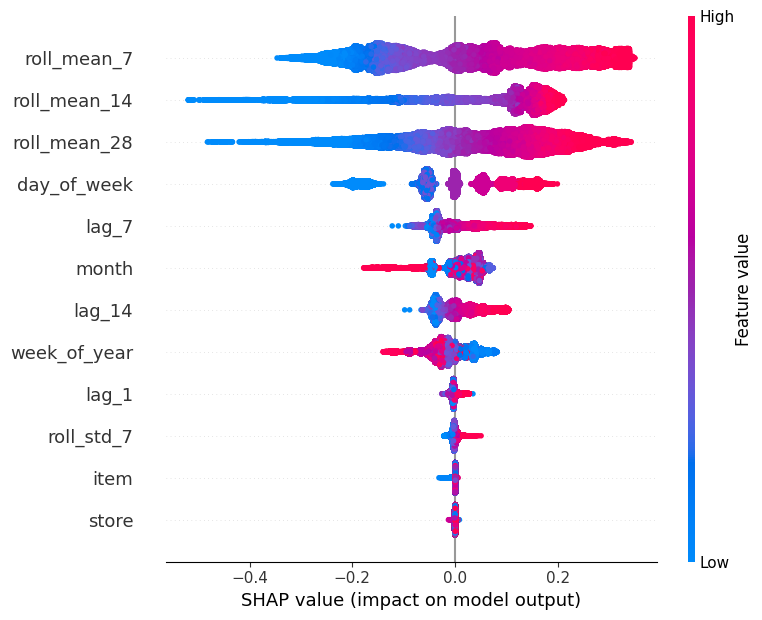

In [ ]:
# Model Interpretability
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

In [ ]:
# =========================
# 5. Save artifacts
# =========================

# Final model selected: XGBoost, based on best RMSE and validated using SHAP for interpretability.
joblib.dump(features, r"outputs/feature_order.pkl")
joblib.dump(xgb_model, r"outputs/demand_forecast_model.pkl")




["c:\\Users\\SupriyaKS\\OneDrive - TheMathCompany Private Limited\\Documents\\Supriya\\Q1'2026\\retail-demand-forecast\\outputs\\demand_forecast_model.pkl"]